# 07 — Porównanie algorytmów (notebook zbiorczy)

Zestawia **5 równorzędnych algorytmów** na tym samym datasecie (Heart Disease UCI) i identycznym pipeline:

1. Regresja logistyczna · 2. Drzewo decyzyjne · 3. Gradient Boosting · 4. Sieć neuronowa (MLP) · 5. Random Forest

> Random Forest był zrealizowany jako pierwszy (`master_notebook`), ale tutaj jest **po prostu kolejnym algorytmem** — wzorcowy jest jedynie *sposób realizacji*, nie sam algorytm.

Porównujemy: **statystyki** (4 metryki), **czas trenowania**, **zachowanie przy małym zbiorze** i **optymalność** (jakość vs koszt). Metryki: Accuracy, F1-Score, ROC-AUC, MCC.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

_root = os.getcwd()
while not os.path.exists(os.path.join(_root, 'data', 'heart.csv')) and _root != os.path.dirname(_root):
    _root = os.path.dirname(_root)
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import learning_curve

from src.preprocessing import load_data, preprocess, split_and_scale
from src import algorithms as alg
from src.model import build_baseline as build_rf, PARAM_GRID as RF_GRID

os.makedirs('plots', exist_ok=True)
os.makedirs('results', exist_ok=True)
RANDOM_STATE = 42
COLORS = ['#2E5FA3', '#E8834A', '#4C9F70', '#B5651D', '#7B5EA7']

## 1. Dane i rejestr algorytmów

Identyczny split jak w notebookach 03–06. Rejestr 5 algorytmów: 4 z `src/algorithms.py` + RF z `src/model.py`.

In [2]:
X, y = preprocess(load_data('data/heart.csv'))
X_train, X_test, X_train_s, X_test_s, y_train, y_test, scaler = split_and_scale(X, y)

# Rejestr 5 RÓWNORZĘDNYCH algorytmów
REGISTRY = {name: dict(slug=cfg['slug'], build=cfg['build'], grid=cfg['grid'])
            for name, cfg in alg.ALGORITHMS.items()}
REGISTRY['Random Forest'] = dict(slug='random_forest', build=build_rf, grid=RF_GRID)
print('Algorytmy w porównaniu:')
for n in REGISTRY:
    print(' -', n)

Algorytmy w porównaniu:
 - Regresja logistyczna
 - Drzewo decyzyjne
 - Gradient Boosting
 - Sieć neuronowa (MLP)
 - Random Forest


### Najlepsze parametry (z notebooków 02–06)

Ładujemy `best_params` z `results/*.json`. RF (którego nie liczy żaden notebook) jest strojony tutaj raz i cache'owany - dzięki temu notebook działa samodzielnie. **Uwaga:** dla pełnych wyników uruchom najpierw notebooki 03–06.

In [3]:
# Dla każdego algorytmu potrzebujemy najlepszych parametrów (best_params).
# Ładujemy je z results/<slug>.json zapisanych przez notebooki 02-06.
# Jeśli któregoś brak (np. RF, którego nie liczy żaden notebook) — stroimy tutaj
# raz i zapisujemy, żeby ten notebook był samowystarczalny.
def ensure_best_params(name, cfg):
    r = alg.load_results(cfg['slug'])
    if r and r.get('best_params') is not None:
        print(f'  [json ] {name:22s} <- results/{cfg["slug"]}.json')
        return r['best_params']
    print(f'  [tuning] {name:22s} brak json — stroję (GridSearchCV)...')
    best, gs = alg.tune(cfg['build'](), cfg['grid'], X_train_s, y_train)
    alg.save_results(cfg['slug'], {
        'name': name, 'slug': cfg['slug'],
        'best_params': gs.best_params_,
        'tuned': alg.evaluate(best, X_test_s, y_test),
    })
    return gs.best_params_

best_params = {name: ensure_best_params(name, cfg) for name, cfg in REGISTRY.items()}

  [json ] Regresja logistyczna   <- results/logistic_regression.json
  [json ] Drzewo decyzyjne       <- results/decision_tree.json
  [json ] Gradient Boosting      <- results/gradient_boosting.json
  [json ] Sieć neuronowa (MLP)   <- results/neural_network.json
  [json ] Random Forest          <- results/random_forest.json


## 2. Kontrolowany benchmark

Wszystkie modele trenowane i mierzone w jednym miejscu, w identycznych warunkach - to gwarantuje uczciwe porównanie czasów i metryk.

In [4]:
# Kontrolowany benchmark w JEDNYM miejscu = sprawiedliwe, spójne warunki.
# Rekonstruujemy każdy model po tuningu z best_params (bez ponownego GridSearch),
# trenujemy raz z pomiarem czasu, liczymy 4 metryki i czas predykcji.
rows, fitted = [], {}
for name, cfg in REGISTRY.items():
    model = cfg['build']()
    model.set_params(**best_params[name])
    model, ft = alg.timed_fit(model, X_train_s, y_train)
    pt = alg.timed_predict(model, X_test_s, repeat=10)
    m = alg.evaluate(model, X_test_s, y_test)
    fitted[name] = model
    rows.append({'Algorytm': name, **m, 'fit_time_s': ft, 'predict_time_s': pt})

df = pd.DataFrame(rows).set_index('Algorytm')
df_metrics = df[['accuracy', 'f1', 'roc_auc', 'mcc']]
LAB = {'accuracy': 'Accuracy', 'f1': 'F1-Score', 'roc_auc': 'ROC-AUC', 'mcc': 'MCC'}
df_metrics.rename(columns=LAB).round(4)

,Accuracy,F1-Score,ROC-AUC,MCC
Algorytm,,,,
Regresja logistyczna,0.8525,0.8475,0.9578,0.7087
Drzewo decyzyjne,0.7541,0.7541,0.8517,0.5184
Gradient Boosting,0.8689,0.8571,0.9448,0.7359
Sieć neuronowa (MLP),0.8689,0.8710,0.9318,0.7546
Random Forest,0.9016,0.8966,0.9481,0.8048


## 3. Porównanie statystyk (4 metryki)

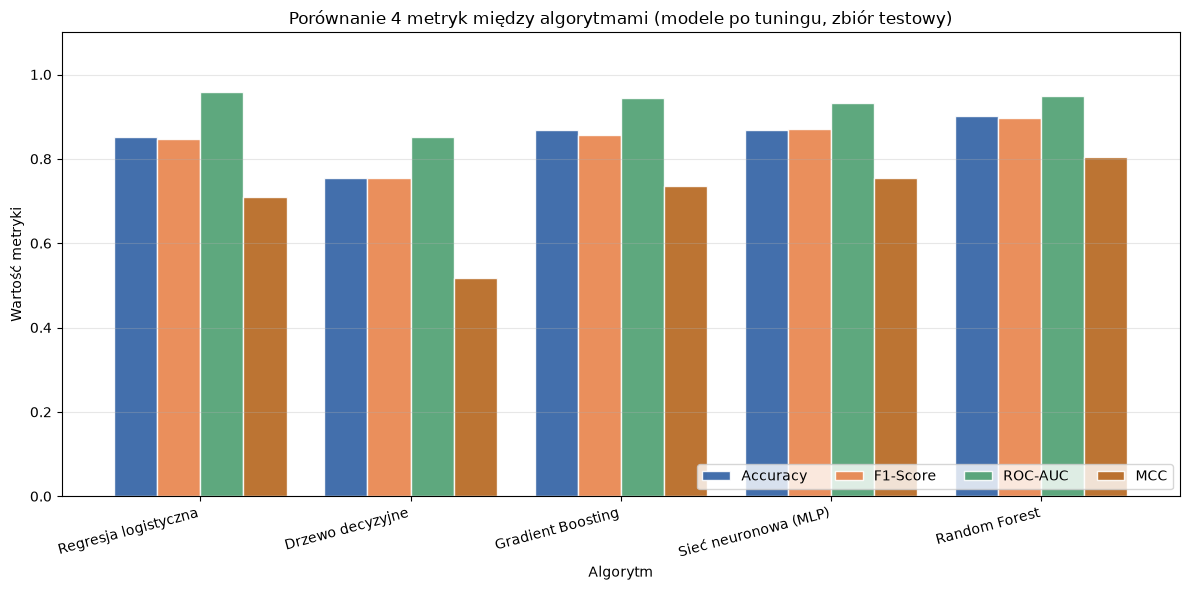

In [5]:
ax = df_metrics.rename(columns=LAB).plot(
    kind='bar', figsize=(12, 6),
    color=['#2E5FA3', '#E8834A', '#4C9F70', '#B5651D'],
    alpha=0.9, edgecolor='white', width=0.82)
ax.set_ylim(0, 1.1); ax.set_ylabel('Wartość metryki')
ax.set_title('Porównanie 4 metryk między algorytmami (modele po tuningu, zbiór testowy)')
ax.legend(loc='lower right', ncol=4)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right'); plt.tight_layout()
plt.savefig('plots/summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### Ranking łączny

In [6]:
# ranking łączny = średnia z 4 metryk (MCC przeskalowany z [-1,1] do [0,1] dla uczciwej średniej)
scaled = df_metrics.copy()
scaled['mcc'] = (scaled['mcc'] + 1) / 2
ranking = df_metrics.assign(SREDNIA=scaled.mean(axis=1)).sort_values('SREDNIA', ascending=False)
print('=== Najlepszy algorytm wg każdej metryki ===')
for m, lab in LAB.items():
    best = df_metrics[m].idxmax()
    print(f'  {lab:9s}: {best:22s} ({df_metrics.loc[best, m]:.4f})')
ranking.rename(columns=LAB).round(4)

=== Najlepszy algorytm wg każdej metryki ===
  Accuracy : Random Forest          (0.9016)
  F1-Score : Random Forest          (0.8966)
  ROC-AUC  : Regresja logistyczna   (0.9578)
  MCC      : Random Forest          (0.8048)


,Accuracy,F1-Score,ROC-AUC,MCC,SREDNIA
Algorytm,,,,,
Random Forest,0.9016,0.8966,0.9481,0.8048,0.9122
Sieć neuronowa (MLP),0.8689,0.8710,0.9318,0.7546,0.8872
Gradient Boosting,0.8689,0.8571,0.9448,0.7359,0.8847
Regresja logistyczna,0.8525,0.8475,0.9578,0.7087,0.8780
Drzewo decyzyjne,0.7541,0.7541,0.8517,0.5184,0.7798


## 4. Różnice w czasie trenowania

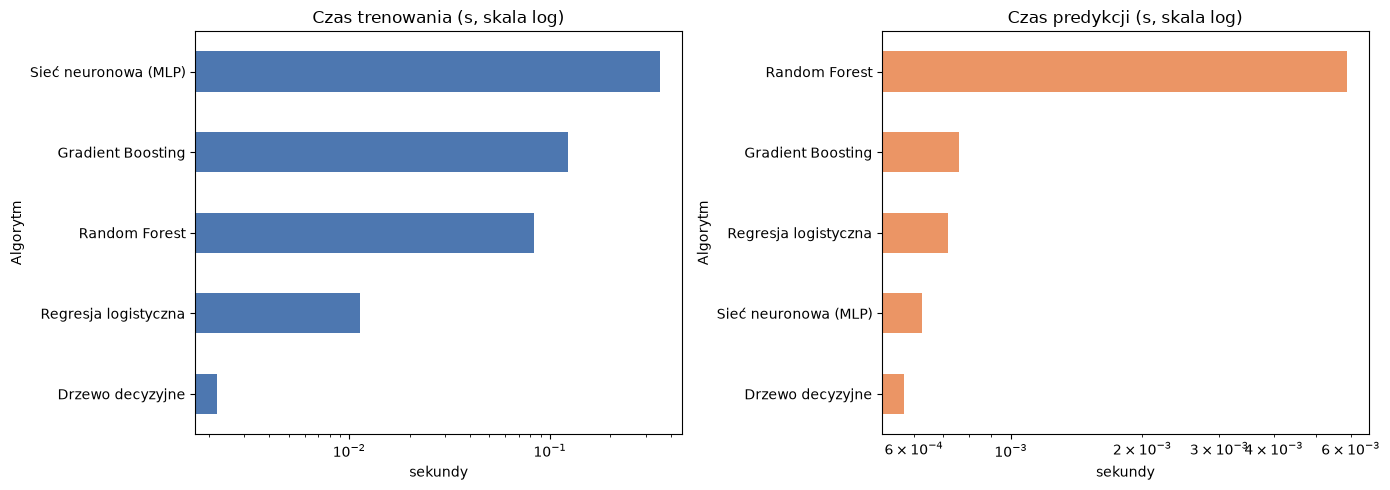

,fit_time_s,predict_time_s,trening_x_wolniej
Algorytm,,,
Drzewo decyzyjne,0.0022,0.00057,1.0
Regresja logistyczna,0.0114,0.00072,5.2
Random Forest,0.0833,0.00587,37.8
Gradient Boosting,0.1225,0.00076,55.5
Sieć neuronowa (MLP),0.3523,0.00063,159.7


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['fit_time_s'].sort_values().plot(kind='barh', ax=axes[0], color='#2E5FA3', alpha=0.85, logx=True)
axes[0].set_title('Czas trenowania (s, skala log)'); axes[0].set_xlabel('sekundy')
df['predict_time_s'].sort_values().plot(kind='barh', ax=axes[1], color='#E8834A', alpha=0.85, logx=True)
axes[1].set_title('Czas predykcji (s, skala log)'); axes[1].set_xlabel('sekundy')
plt.tight_layout()
plt.savefig('plots/summary_timing.png', dpi=150, bbox_inches='tight')
plt.show()

t = df[['fit_time_s', 'predict_time_s']].copy()
t['trening_x_wolniej'] = df['fit_time_s'] / df['fit_time_s'].min()
t.sort_values('fit_time_s').round({'fit_time_s': 4, 'predict_time_s': 5, 'trening_x_wolniej': 1})

## 5. Zachowanie przy małym zbiorze (krzywe uczenia)

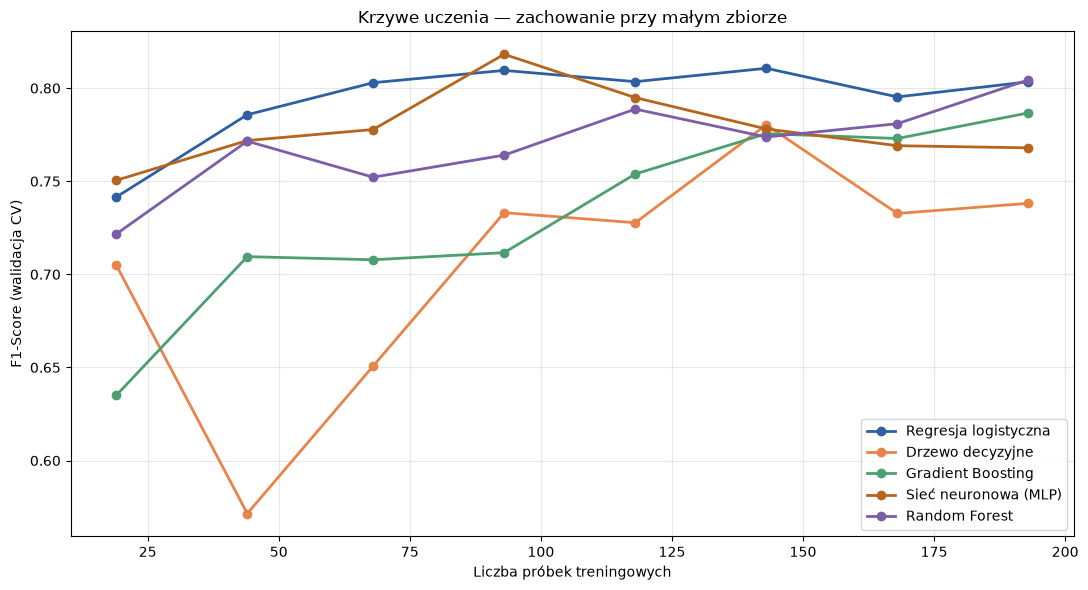

,F1_maly_zbior,F1_pelny_zbior,n_min,n_max,przyrost_F1
Sieć neuronowa (MLP),0.7505,0.7679,19.0,193.0,0.0174
Regresja logistyczna,0.7415,0.8034,19.0,193.0,0.0619
Random Forest,0.7217,0.8045,19.0,193.0,0.0828
Drzewo decyzyjne,0.7050,0.7382,19.0,193.0,0.0331
Gradient Boosting,0.6350,0.7867,19.0,193.0,0.1517


In [8]:
# Krzywe uczenia: F1 (walidacja CV) w funkcji liczby próbek treningowych.
# Pokazuje, które algorytmy radzą sobie przy MAŁEJ ilości danych, a które są
# "głodne danych" (startują nisko, dużo zyskują z dodatkowych próbek).
train_sizes = np.linspace(0.1, 1.0, 8)
plt.figure(figsize=(11, 6))
small = {}
for (name, model), c in zip(fitted.items(), COLORS):
    ts, tr, va = learning_curve(clone(model), X_train_s, y_train, cv=5,
                                scoring='f1', train_sizes=train_sizes, n_jobs=-1)
    v = va.mean(axis=1)
    plt.plot(ts, v, 'o-', color=c, lw=2, label=name)
    small[name] = {'F1_maly_zbior': float(v[0]), 'F1_pelny_zbior': float(v[-1]),
                   'n_min': int(ts[0]), 'n_max': int(ts[-1])}
plt.xlabel('Liczba próbek treningowych'); plt.ylabel('F1-Score (walidacja CV)')
plt.title('Krzywe uczenia — zachowanie przy małym zbiorze')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('plots/summary_small_data.png', dpi=150, bbox_inches='tight')
plt.show()

sd = pd.DataFrame(small).T
sd['przyrost_F1'] = sd['F1_pelny_zbior'] - sd['F1_maly_zbior']
sd.sort_values('F1_maly_zbior', ascending=False).round(4)

## 6. Optymalność: jakość vs koszt

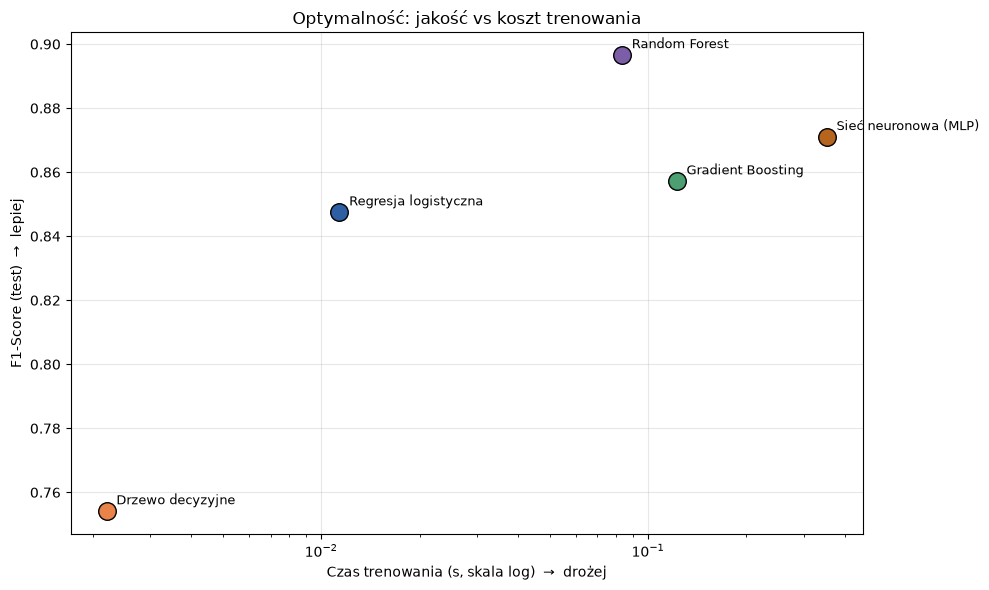

In [9]:
# Optymalność: jakość (F1) vs koszt (czas trenowania). Najlepsze modele są w
# lewym-górnym rogu (wysoki F1, krótki trening).
fig, ax = plt.subplots(figsize=(10, 6))
for (name, r), c in zip(df.iterrows(), COLORS):
    ax.scatter(r['fit_time_s'], r['f1'], s=160, color=c, edgecolor='black', zorder=3)
    ax.annotate(name, (r['fit_time_s'], r['f1']), xytext=(7, 5),
                textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Czas trenowania (s, skala log)  →  drożej')
ax.set_ylabel('F1-Score (test)  →  lepiej')
ax.set_title('Optymalność: jakość vs koszt trenowania')
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('plots/summary_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Kluczowe obserwacje (policzone)

In [10]:
print('=== KLUCZOWE OBSERWACJE (policzone) ===\n')
print('Jakość (metryki):')
for m, lab in LAB.items():
    b = df_metrics[m].idxmax()
    print(f'  najlepszy {lab:9s}: {b:22s} ({df_metrics.loc[b, m]:.4f})')
print(f'\nRanking łączny (średnia metryk): {ranking.index[0]}')
print('\nCzas trenowania:')
print(f'  najszybszy : {df["fit_time_s"].idxmin():22s} ({df["fit_time_s"].min() * 1000:8.1f} ms)')
print(f'  najwolniej.: {df["fit_time_s"].idxmax():22s} ({df["fit_time_s"].max() * 1000:8.1f} ms)')
print(f'  rozpiętość : x{df["fit_time_s"].max() / df["fit_time_s"].min():.0f}')
print('\nMały zbiór:')
print(f'  najlepszy przy najmniej danych : {sd["F1_maly_zbior"].idxmax():22s} (F1={sd["F1_maly_zbior"].max():.3f})')
print(f'  najbardziej "głodny danych"    : {sd["przyrost_F1"].idxmax():22s} (przyrost F1 +{sd["przyrost_F1"].max():.3f})')

=== KLUCZOWE OBSERWACJE (policzone) ===

Jakość (metryki):
  najlepszy Accuracy : Random Forest          (0.9016)
  najlepszy F1-Score : Random Forest          (0.8966)
  najlepszy ROC-AUC  : Regresja logistyczna   (0.9578)
  najlepszy MCC      : Random Forest          (0.8048)

Ranking łączny (średnia metryk): Random Forest

Czas trenowania:
  najszybszy : Drzewo decyzyjne       (     2.2 ms)
  najwolniej.: Sieć neuronowa (MLP)   (   352.3 ms)
  rozpiętość : x160

Mały zbiór:
  najlepszy przy najmniej danych : Sieć neuronowa (MLP)   (F1=0.750)
  najbardziej "głodny danych"    : Gradient Boosting      (przyrost F1 +0.152)


## 8. Wnioski

Wnioski opierają się na liczbach policzonych w komórkach powyżej (dla modeli iteracyjnych — MLP — wartości mogą się nieznacznie wahać między uruchomieniami, ale kierunek jest stabilny).

**Porównanie statystyk (4 metryki).** Różne metryki wskazują różnych liderów: w rankingu łącznym najlepszy jest **Random Forest** (najwyższe Accuracy, F1 i MCC), ale najlepsze **ROC-AUC** (niezależne od progu) ma **regresja logistyczna**. Modele ensemble i liniowy są wzajemnie konkurencyjne, a **drzewo decyzyjne** wyraźnie odstaje we wszystkich czterech metrykach. MCC i ROC-AUC różnicują modele mocniej niż samo accuracy - dlatego są w komplecie.

**Różnice w czasie trenowania.** Rozpiętość ~2 rzędy wielkości (skala log): **drzewo** (~1 ms) i **regresja** (~4 ms) trenują się błyskawicznie, **Random Forest** i **Gradient Boosting** są kilkadziesiąt razy wolniejsze (dziesiątki drzew; boosting jest sekwencyjny, więc słabo się zrównolegla), a **sieć MLP** jest najwolniejsza (~200× wolniej od drzewa - iteracyjna optymalizacja). Czas *predykcji* jest znacznie wyrównany — główny koszt ponosimy przy treningu.

**Różnice przy małym zbiorze.** Krzywe uczenia (F1 z CV vs liczba próbek) pokazują wzorzec bias–wariancja. Najsilniej „głodny danych" jest **Gradient Boosting** - startuje najniżej i najwięcej zyskuje z dodatkowych próbek (największy przyrost F1). **Regresja logistyczna** i **Random Forest** rosną stabilnie i osiągają najwyższe F1 na pełnym zbiorze - najlepiej wykorzystują dane. **Sieć MLP** ma krzywą niemal płaską (mały przyrost), lecz jej pułap CV jest przeciętny; **drzewo** pozostaje najsłabsze na każdym rozmiarze. Przy zaledwie ~240 próbkach treningowych modele pojemne (zwłaszcza boosting) niosą realne ryzyko niedouczenia — szczegóły w tabeli powyżej.

**Optymalność (jakość vs koszt).** Na wykresie Pareto interesuje nas lewy-górny róg (wysoki F1, krótki trening). **Regresja logistyczna** leży blisko frontu efektywności - bardzo dobra jakość (najlepsze ROC-AUC) przy niemal najniższym koszcie i pełnej interpretowalności. **Random Forest** oferuje najlepsze metryki łączne, ale ~kilkadziesiąt razy drożej; **MLP** jest najdroższy i nie przewyższa prostszych modeli na tak małym zbiorze tabelarycznym.

**Rekomendacja dla tego problemu.** Mały, tabelaryczny, zbalansowany zbiór + wymóg interpretowalności (kontekst medyczny):
- **Regresja logistyczna** - najlepszy kompromis jakość / koszt / interpretowalność (najlepsze ROC-AUC, ~ms trening, jawne współczynniki).
- **Random Forest / Gradient Boosting** - gdy priorytetem jest maksymalna jakość łączna (RF ma najlepszy ranking), akceptując wyższy koszt i mniejszą przejrzystość.
- **Drzewo decyzyjne** - najbardziej czytelny baseline (jawne reguły), ale najsłabszy jakościowo.
- **Sieć MLP** - cenna dydaktycznie; na małych danych tabelarycznych nie dominuje.
